In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Rutas
DATA_RAW = os.path.join('..', 'data', 'raw')

# Estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ Librerías cargadas")

✓ Librerías cargadas


In [2]:
calendario   = pd.read_csv(os.path.join(DATA_RAW, 'calendario_ciudad.csv'),      parse_dates=['fecha'])
clientes     = pd.read_csv(os.path.join(DATA_RAW, 'clientes.csv'),               parse_dates=['fecha_alta'])
inversion    = pd.read_csv(os.path.join(DATA_RAW, 'inversion_medios_semanal.csv'),parse_dates=['semana_inicio','semana_fin'])
pedidos      = pd.read_csv(os.path.join(DATA_RAW, 'pedidos.csv'),                 parse_dates=['fecha_pedido'])
productos    = pd.read_csv(os.path.join(DATA_RAW, 'productos.csv'))
trafico      = pd.read_csv(os.path.join(DATA_RAW, 'trafico_tienda_web_diario.csv'),parse_dates=['fecha'])
ventas_lin   = pd.read_csv(os.path.join(DATA_RAW, 'ventas_lineas.csv'),           parse_dates=['fecha_venta'])

tablas = {
    'calendario':  calendario,
    'clientes':    clientes,
    'inversion':   inversion,
    'pedidos':     pedidos,
    'productos':   productos,
    'trafico':     trafico,
    'ventas_lin':  ventas_lin
}

print("✓ Todos los CSV cargados")

✓ Todos los CSV cargados


In [3]:
for nombre, df in tablas.items():
    nulos = df.isnull().sum().sum()
    print(f"\n{'='*50}")
    print(f"  {nombre.upper()}")
    print(f"  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}  |  Nulos totales: {nulos}")
    print(f"  Columnas: {list(df.columns)}")
    nulos_col = df.isnull().sum()
    if nulos_col.any():
        print(f"  Nulos por columna:\n{nulos_col[nulos_col > 0]}")


  CALENDARIO
  Filas: 18,270  |  Columnas: 18  |  Nulos totales: 0
  Columnas: ['fecha', 'ciudad', 'anio', 'mes', 'dia_semana_num', 'dia_semana', 'fin_de_semana', 'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag', 'temperatura_media_c', 'lluvia_indice', 'turismo_indice', 'incidencia_ecommerce_flag']

  CLIENTES
  Filas: 600,000  |  Columnas: 9  |  Nulos totales: 0
  Columnas: ['id_cliente', 'ciudad_residencia', 'sexo', 'edad', 'segmento', 'fecha_alta', 'sensibilidad_descuento', 'propension_omnicanal', 'canal_preferido']

  INVERSION
  Filas: 20,880  |  Columnas: 9  |  Nulos totales: 0
  Columnas: ['semana_inicio', 'semana_fin', 'anio', 'semana_iso', 'ciudad', 'canal_medio', 'tipo_medio', 'inversion_eur', 'objetivo_principal']

  PEDIDOS
  Filas: 8,000,000  |  Columnas: 9  |  Nulos totales: 0
  Columnas: ['id_pedido', 'fecha_pedido', 'id_cliente', 'ciudad', 'canal_venta', 'num_articulos', 'importe_

In [4]:
print("=== VENTAS NETAS (ventas_lineas) ===")
display(ventas_lin[['venta_neta_sin_iva_eur', 'pvp_bruto_eur',
                     'descuento_pct', 'cantidad_unidades']].describe().round(2))

print("\n=== INVERSIÓN EN MEDIOS ===")
display(inversion[['inversion_eur']].describe().round(2))

print("\n=== PEDIDOS ===")
display(pedidos[['importe_neto_sin_iva_eur', 'num_articulos',
                  'coste_total_eur']].describe().round(2))

print("\n=== TRÁFICO WEB/TIENDA ===")
display(trafico[['sesiones_web', 'pedidos_online', 'visitas_tienda',
                  'tasa_conversion_web_pct']].describe().round(2))

=== VENTAS NETAS (ventas_lineas) ===


,venta_neta_sin_iva_eur,pvp_bruto_eur,descuento_pct,cantidad_unidades
count,8000000.00,8000000.00,8000000.00,8000000.00
mean,96.01,100.01,4.00,2.50
std,53.12,54.77,6.63,1.12
min,16.00,20.00,0.00,1.00
25%,51.11,53.35,0.00,2.00
50%,88.15,92.31,0.00,2.00
75%,130.97,137.15,10.00,3.00
max,240.00,240.00,20.00,4.00



=== INVERSIÓN EN MEDIOS ===


,inversion_eur
count,20880.00
mean,2873.56
std,2194.84
min,35.02
25%,1383.51
50%,2307.20
75%,3695.42
max,25120.98



=== PEDIDOS ===


,importe_neto_sin_iva_eur,num_articulos,coste_total_eur
count,8000000.00,8000000.00,8000000.00
mean,96.01,2.50,37.50
std,53.12,1.12,21.12
min,16.00,1.00,6.00
25%,51.11,2.00,19.83
50%,88.15,2.00,34.12
75%,130.97,3.00,50.92
max,240.00,4.00,107.97



=== TRÁFICO WEB/TIENDA ===


,sesiones_web,pedidos_online,visitas_tienda,tasa_conversion_web_pct
count,18270.00,18270.00,18270.00,18270.00
mean,205.36,5.15,29.06,0.04
std,126.02,3.36,15.38,0.01
min,10.00,0.00,2.00,0.02
25%,116.00,3.00,18.00,0.03
50%,177.00,4.00,27.00,0.03
75%,266.00,7.00,38.00,0.05
max,980.00,25.00,131.00,0.07


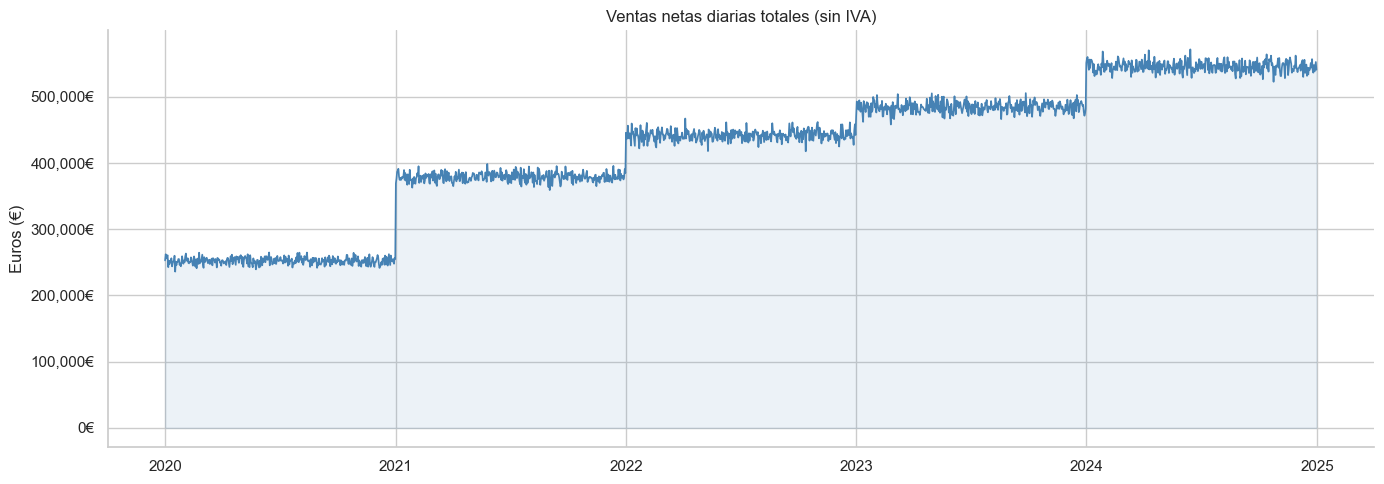

In [5]:
ventas_diarias = (
    ventas_lin
    .groupby('fecha_venta')['venta_neta_sin_iva_eur']
    .sum()
    .reset_index()
    .rename(columns={'fecha_venta': 'fecha', 'venta_neta_sin_iva_eur': 'venta_neta'})
)

fig, ax = plt.subplots()
ax.plot(ventas_diarias['fecha'], ventas_diarias['venta_neta'], linewidth=1.2, color='steelblue')
ax.fill_between(ventas_diarias['fecha'], ventas_diarias['venta_neta'], alpha=0.1, color='steelblue')
ax.set_title('Ventas netas diarias totales (sin IVA)')
ax.set_ylabel('Euros (€)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
plt.tight_layout()
plt.show()

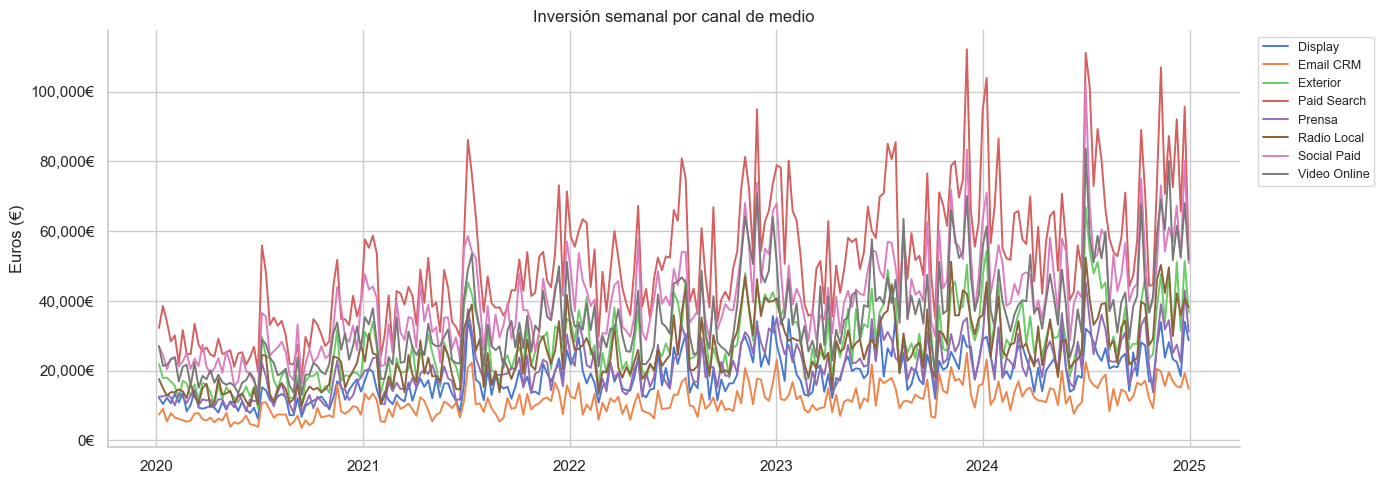


Canales disponibles:
['Paid Search' 'Social Paid' 'Video Online' 'Display' 'Email CRM'
 'Radio Local' 'Exterior' 'Prensa']


In [6]:
inv_canal = (
    inversion
    .groupby(['semana_inicio', 'canal_medio'])['inversion_eur']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots()
for canal, grupo in inv_canal.groupby('canal_medio'):
    ax.plot(grupo['semana_inicio'], grupo['inversion_eur'], label=canal, linewidth=1.4)

ax.set_title('Inversión semanal por canal de medio')
ax.set_ylabel('Euros (€)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\nCanales disponibles:")
print(inversion['canal_medio'].unique())

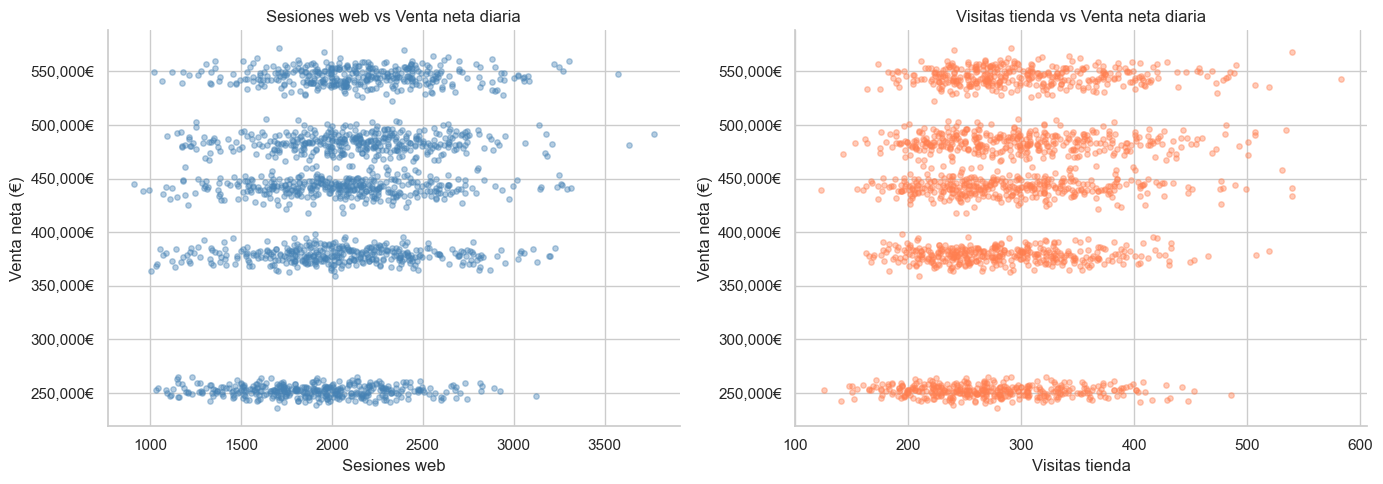

Correlación sesiones web  ↔ venta neta: 0.194
Correlación visitas tienda ↔ venta neta: 0.157


In [7]:
# Agregamos ventas por día
ventas_dia = (
    ventas_lin.groupby('fecha_venta')['venta_neta_sin_iva_eur']
    .sum().reset_index()
    .rename(columns={'fecha_venta': 'fecha', 'venta_neta_sin_iva_eur': 'venta_neta'})
)

# Agregamos sesiones web por día (sumando ciudades)
trafico_dia = (
    trafico.groupby('fecha')[['sesiones_web', 'pedidos_online', 'visitas_tienda']]
    .sum().reset_index()
)

merged = pd.merge(ventas_dia, trafico_dia, on='fecha', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(merged['sesiones_web'], merged['venta_neta'],
                alpha=0.4, s=15, color='steelblue')
axes[0].set_title('Sesiones web vs Venta neta diaria')
axes[0].set_xlabel('Sesiones web')
axes[0].set_ylabel('Venta neta (€)')

axes[1].scatter(merged['visitas_tienda'], merged['venta_neta'],
                alpha=0.4, s=15, color='coral')
axes[1].set_title('Visitas tienda vs Venta neta diaria')
axes[1].set_xlabel('Visitas tienda')
axes[1].set_ylabel('Venta neta (€)')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

plt.tight_layout()
plt.show()

corr_web   = merged['sesiones_web'].corr(merged['venta_neta'])
corr_tiend = merged['visitas_tienda'].corr(merged['venta_neta'])
print(f"Correlación sesiones web  ↔ venta neta: {corr_web:.3f}")
print(f"Correlación visitas tienda ↔ venta neta: {corr_tiend:.3f}")